# Bolometric Light Curve of SN2008D

This notebook demonstrates how to compute the bolometric light curve for SN2008D using Gopreaux.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from caat import CAAT, SNCollection, GP3D, Kernel, SNModel, SN
from sklearn.gaussian_process.kernels import RBF
from astropy import units as u

import logging
logging.getLogger().setLevel(logging.ERROR)
from caat.utils import WLE
mpl.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

In [2]:
colors= ['#e51f00', '#ffaa00', '#59b359', '#00c2f2', '#502db3', '#f2b6de']

## Loading the IIP SNe collection

In [3]:
ib = SNCollection(sntype="SESNe", snsubtype="SNIb")
norm_set = SNCollection(sntype="SESNe")

print("Ib SNe in collection: %i"%len(ib.sne))

Ib SNe in collection: 48


In [4]:
CAAT().get_sne_by_type("SESNe", snsubtype="SNIb")

array(['SN2016adj', 'SN2004dk', 'SN2019tsf', 'SN2010O', 'SN2007C',
       'SN2021uhk', 'SN2019yvr', 'SN2023dtc', 'SN2019dge', 'SN2019dgz',
       'SN2012au', 'SN2009jf', 'SN2019oys', 'SN2018beh', 'SN2007uy',
       'SN2022nyo', 'SN2021niq', 'SN2011am', 'SN2022hgk', 'SN2020hvp',
       'SN2006dn', 'SN2017bgu', 'SN2016bau', 'SN2010cn', 'SN2003gk',
       'SN2022ryd', 'SN2018alc', 'SN2001ej', 'SN2004ao', 'SN2004gq',
       'SN2004gv', 'SN2005bf', 'SN2005hg', 'SN2006F', 'SN2006cb',
       'SN2006el', 'SN2006ep', 'SN2006fo', 'SN2006gi', 'SN2006lc',
       'SN2006ld', 'SN2006lv', 'SN2007ag', 'SN2007ke', 'SN2007kj',
       'SN2008D', 'SN2009er', 'SN2009iz'], dtype=object)

## Fitting the 2D GP surface

In [24]:
kernel = Kernel(RBF([np.log(10.0), np.log10(500.0)], (0.1, 4.0)))

filts = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'g', 'c', 'V', 'r', 'o', 'i', 'H', 'J', 'Ks']
phasemin    = -20
phasemax    =  100   
log_transform = 30   # log-space offset
mangle_sed  = True   # Using shifted wavelengths for better SED prediction

gp = GP3D(
    ib,
    kernel,
    filts,
    phasemin,
    phasemax,
    set_to_normalize=norm_set,
    log_transform=log_transform,
    mangle_sed=mangle_sed,
)

### Optimising kernel hyperparameters


In [25]:
kernel_params = gp.optimize_hyperparams(subtract_polynomial=True)

optimized = np.asarray(
    [np.median([k[i] for k in kernel_params])
     for i in range(len(kernel_params[0]))]
)
print("Optimised kernel hyperparameters:", np.exp(optimized))

Optimised kernel hyperparameters: [3.74390041 1.2652293 ]


### Fit each SN and build the template surface

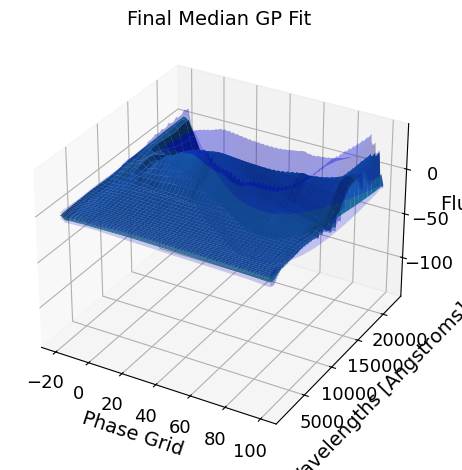

In [26]:
snmodel = gp.predict(
    plot=False,
    subtract_polynomial=True,
    fit_separately=True,
)

## Reading a saved GP model for SNe type Ib

In [20]:
snmodel = SNModel(
    surface="SESNe_SNIb_GP_model.fits",
)

## Reading in data for a SN

In [22]:
from caat import DataCube, SN

SN08D = SN(name="SN2008D")

# cube = DataCube(sn=SN08D, a_v=0.6*3.1) # from Modjaz et al. 2009: a_v=0.6*3.1

# cube.measure_flux_in_filter(overwrite=True, save=True) # this overwrites the existing datacube for the SN

## Fit the SN data 

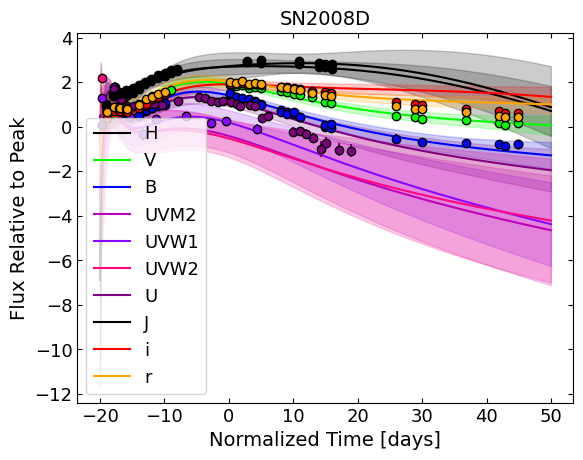

In [23]:
snmodel.fit_photometry(
    sn_to_fit=SN08D, 
    show=True,
    keep_new_fit=True
)


## Generating SEDs of the SN on a grid of phases

In [8]:
print("Wavelength range: %.0f – %.0f A"%(snmodel.min_wl, snmodel.max_wl))
print(f"Phase range: %.1f – %.1f days"\
      %(snmodel.min_phase, snmodel.max_phase))

Wavelength range: 1530 – 22115 A
Phase range: -20.0 – 50.0 days


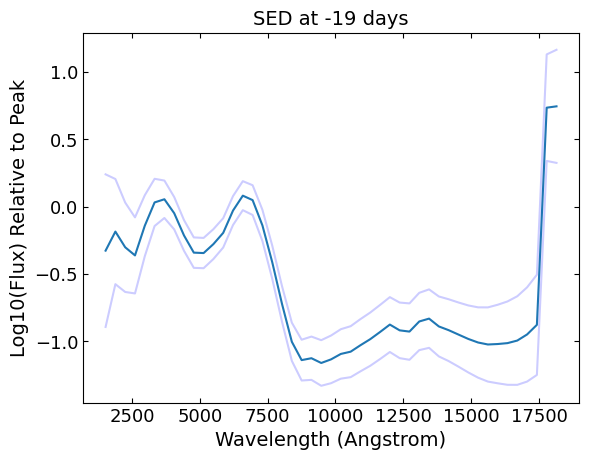

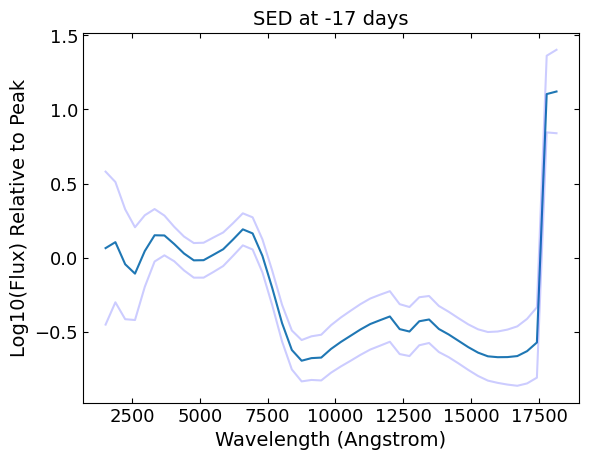

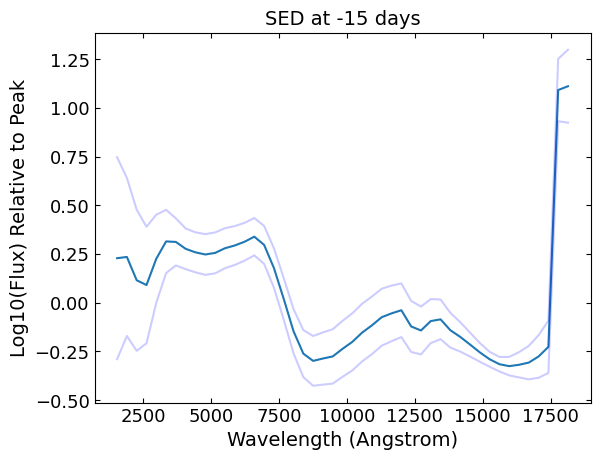

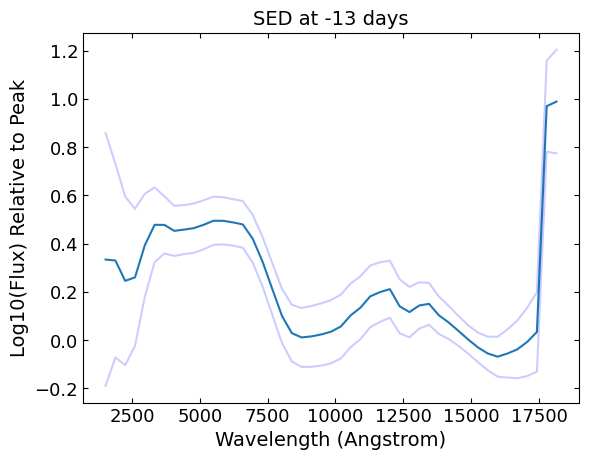

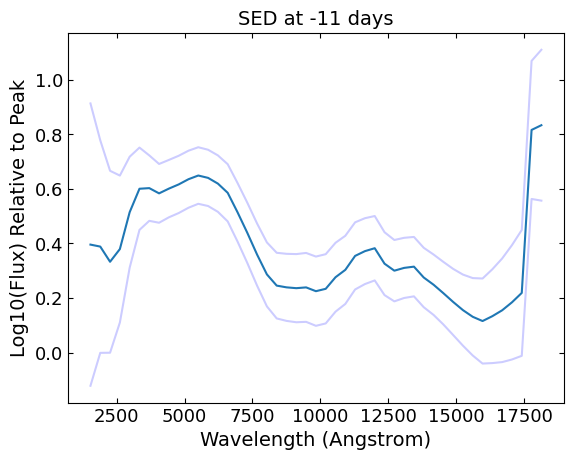

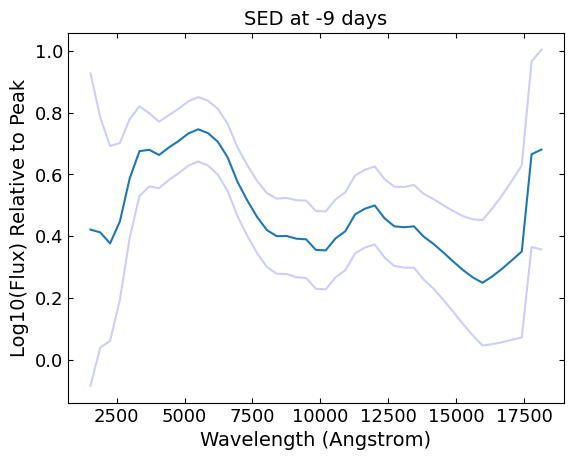

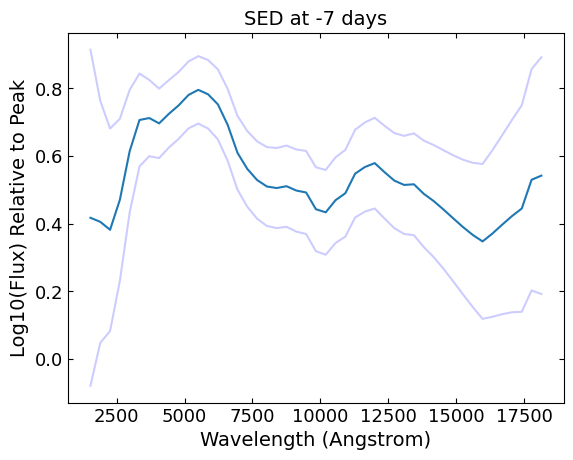

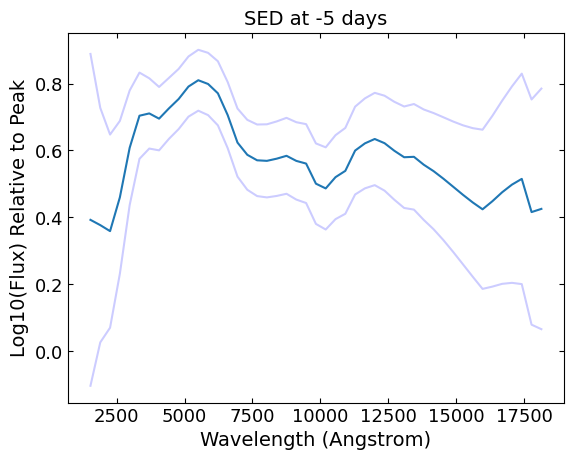

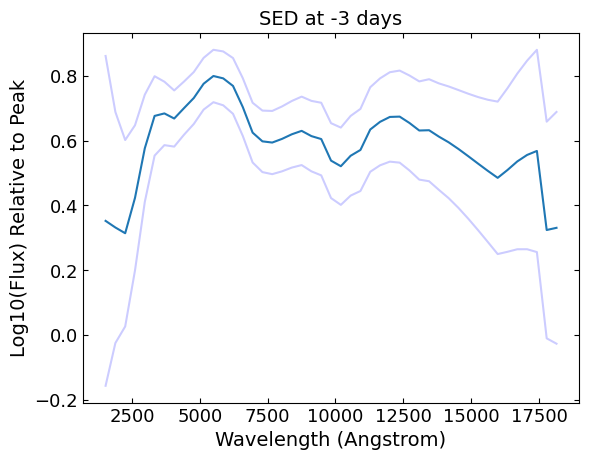

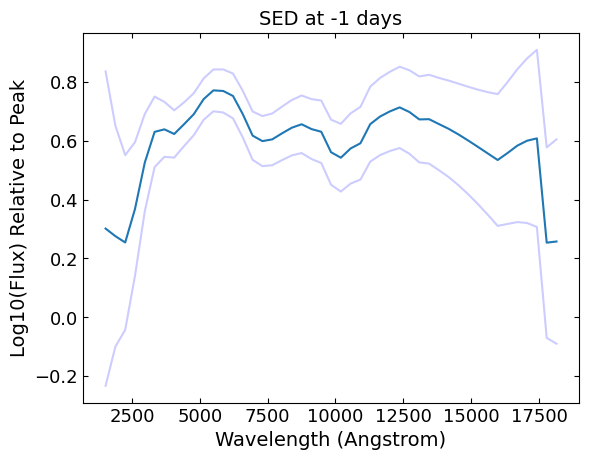

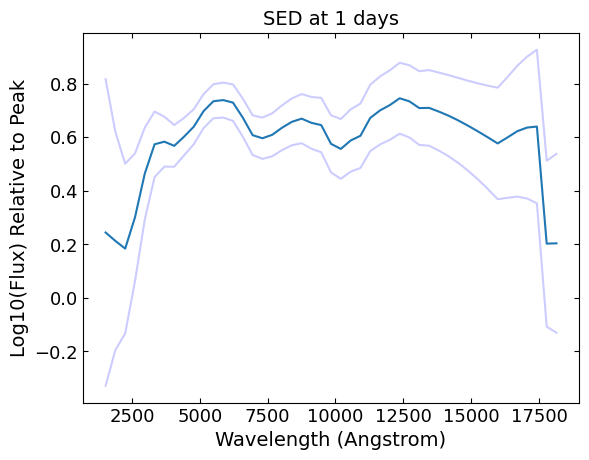

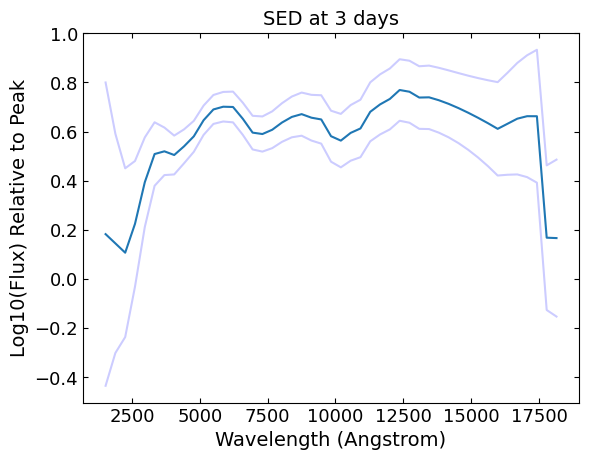

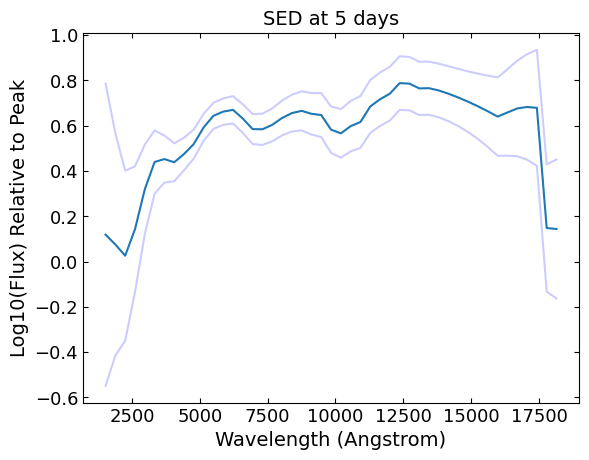

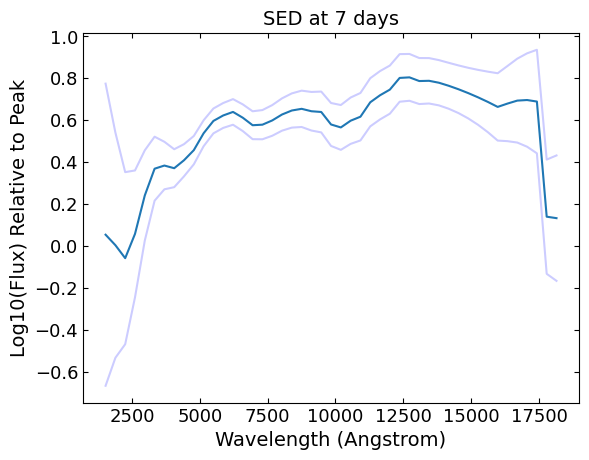

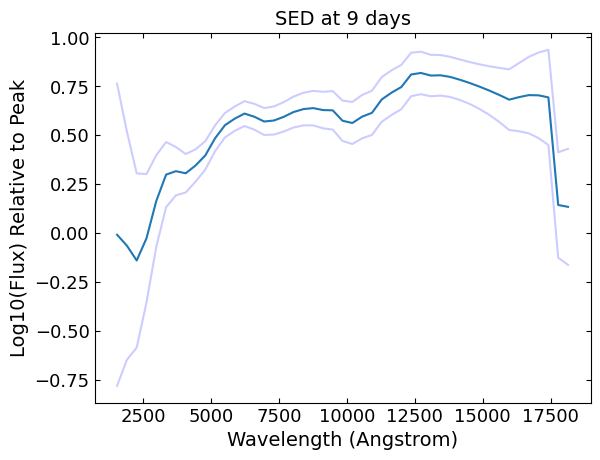

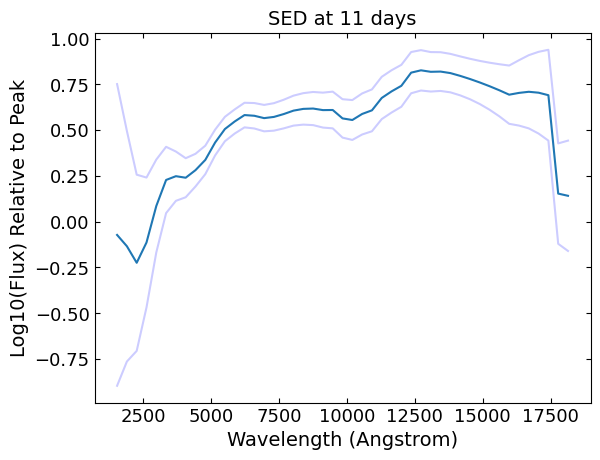

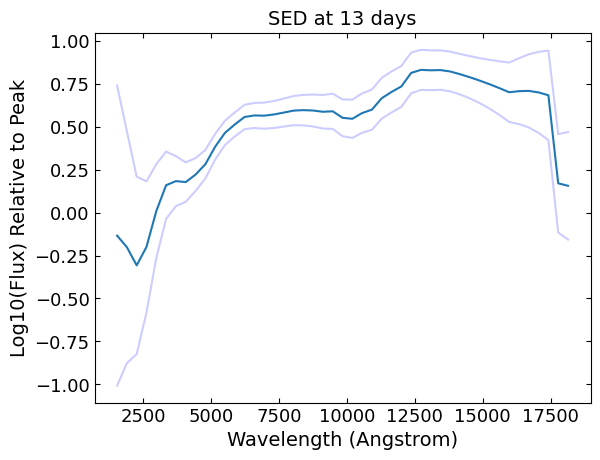

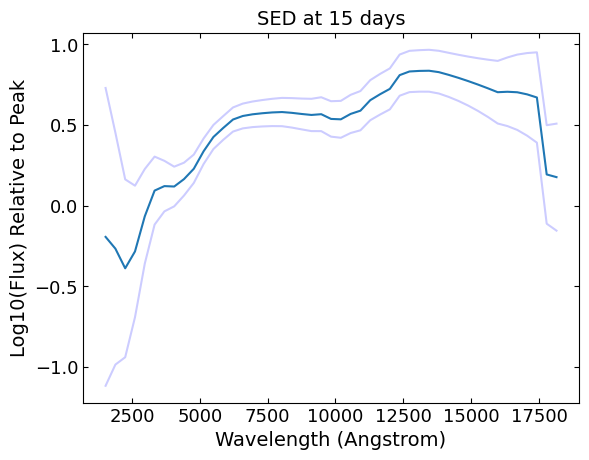

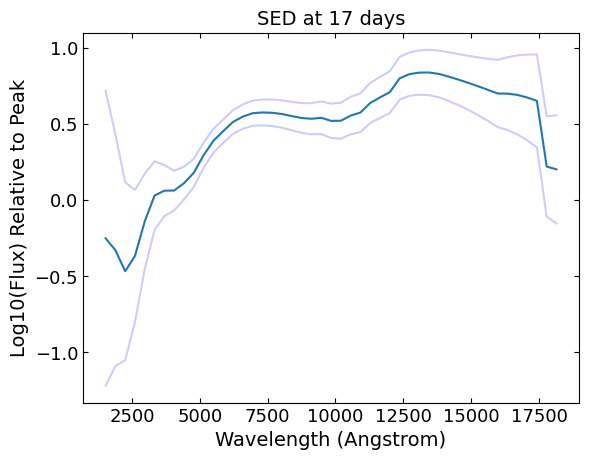

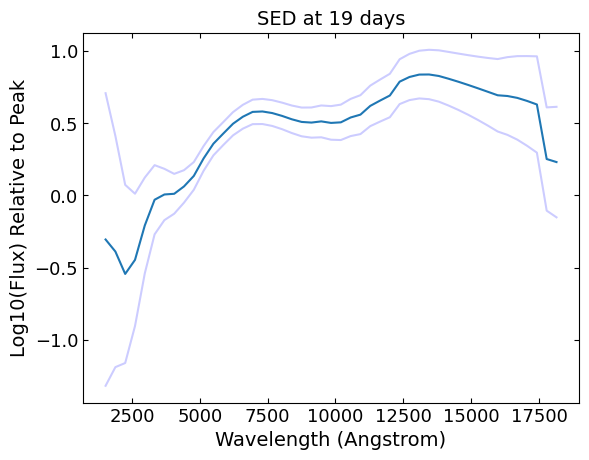

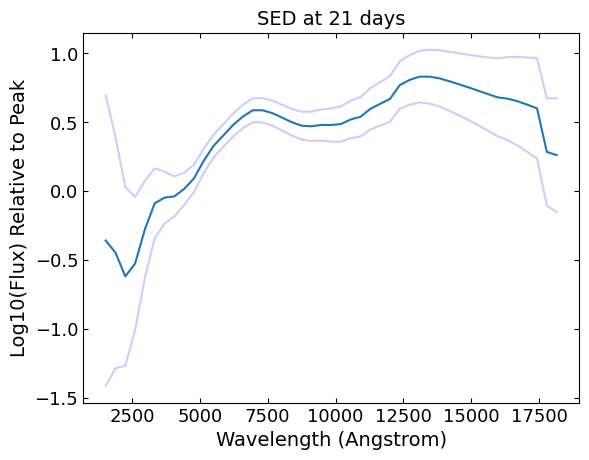

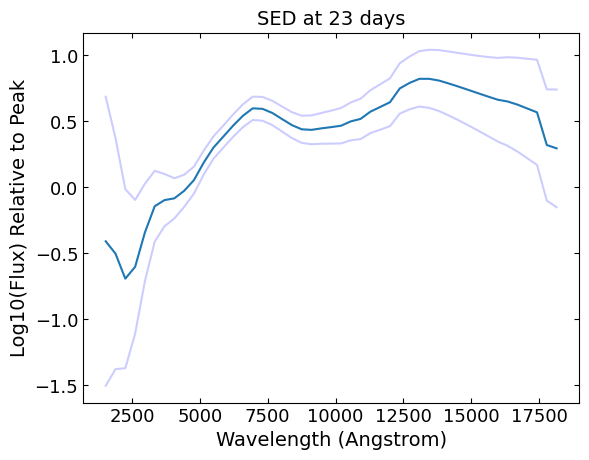

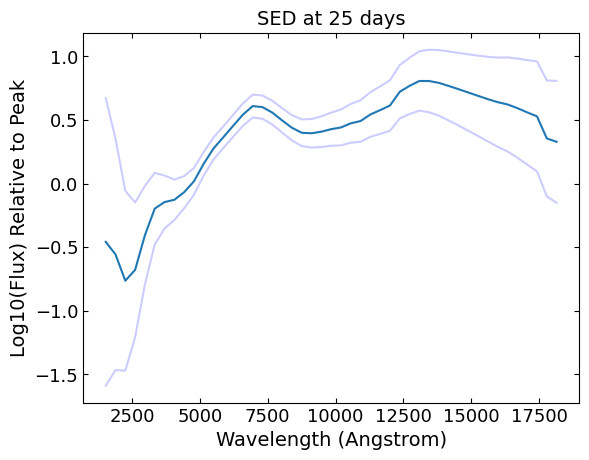

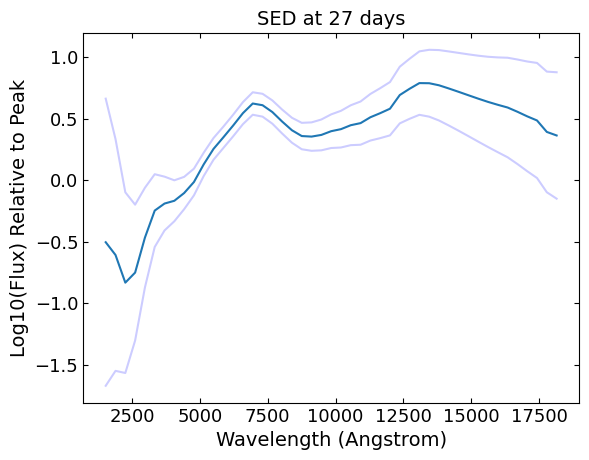

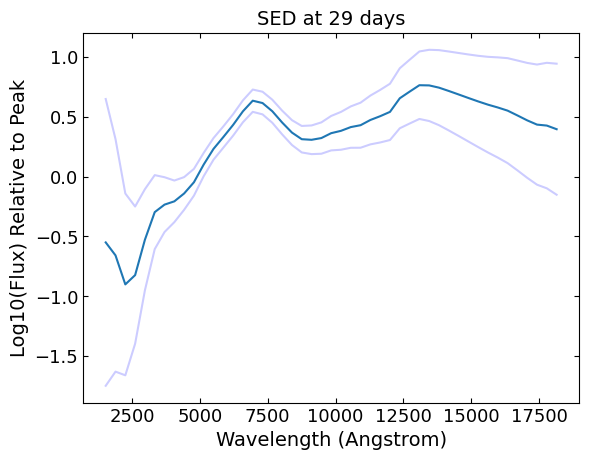

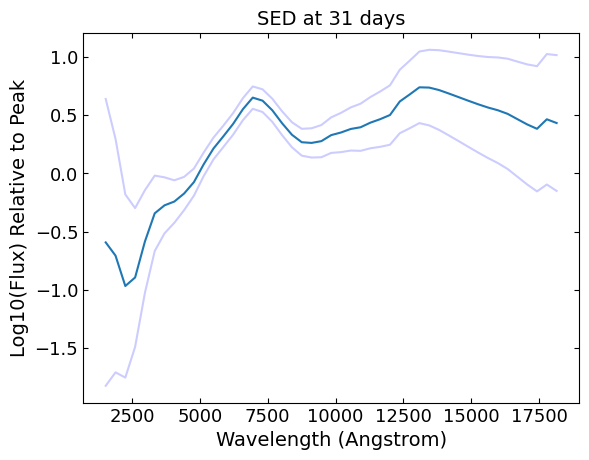

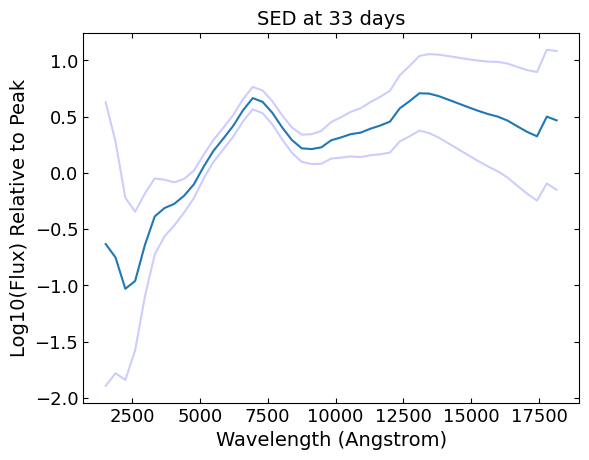

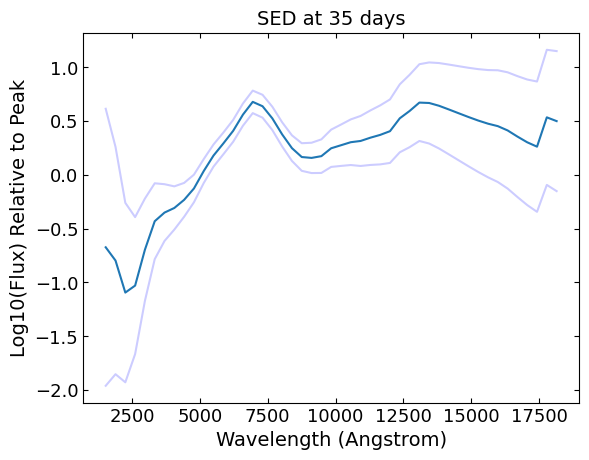

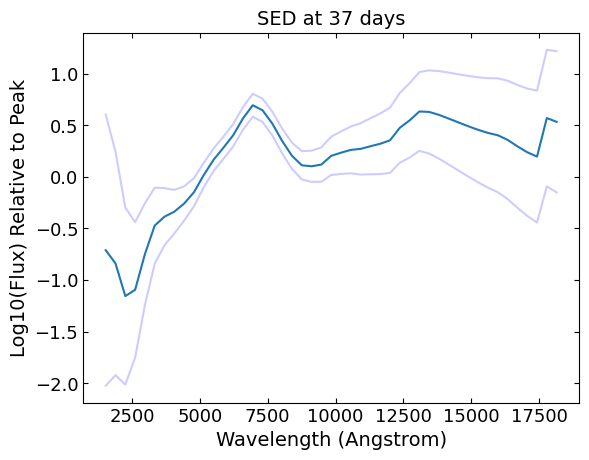

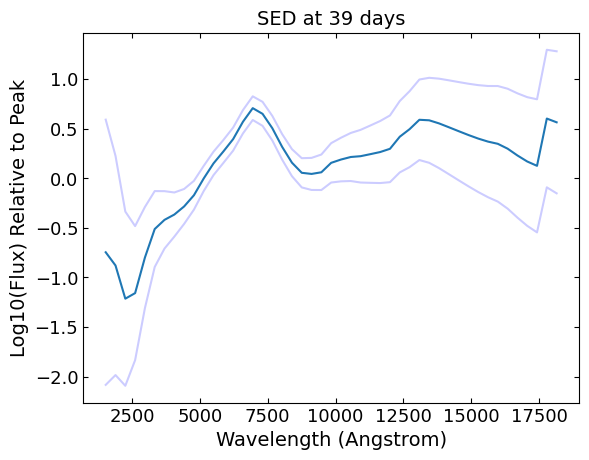

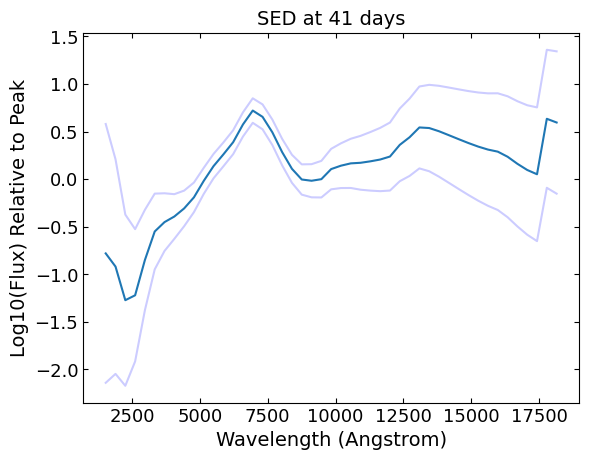

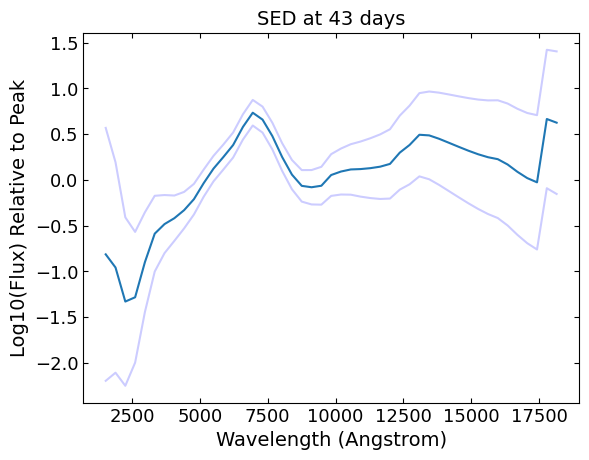

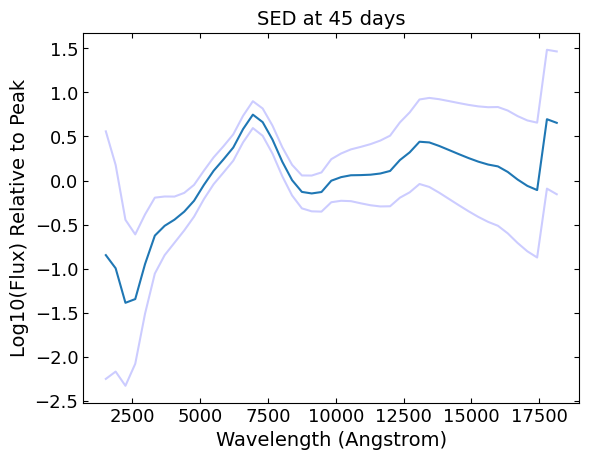

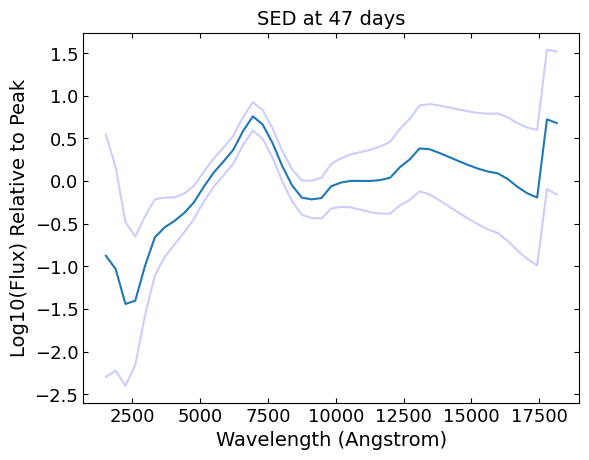

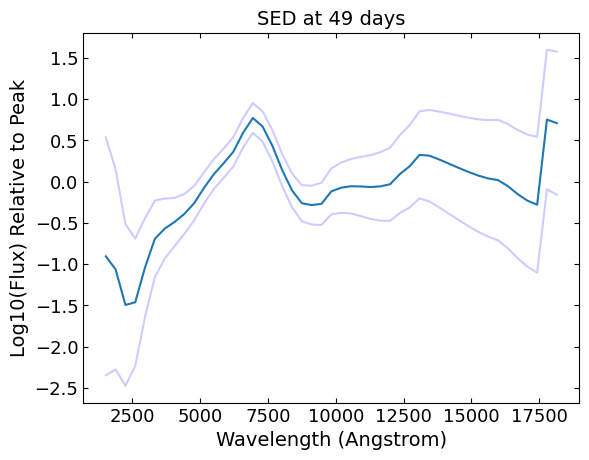

In [9]:
# reference-band
zp_peak    = SN08D.zps[SN08D.info["peak_filt"]]
f_peak_ref = zp_peak * 1e-11 * 10 ** (-0.4 * SN08D.info["peak_mag"])
f_peak_ref_log = np.log10(f_peak_ref)

# phase grid
phase_min, phase_max, phase_step = -19, 49, 2 
phases = np.arange(phase_min, phase_max + phase_step, phase_step)

F_bol   = np.zeros(len(phases))
F_sigma = np.zeros(len(phases))
F_up = np.zeros(len(phases))
F_low = np.zeros(len(phases))
F_UV = np.zeros(len(phases))
F_OPT = np.zeros(len(phases))
F_NIR = np.zeros(len(phases))

uv_opt_boundary = 0.5 * (WLE['U'] + WLE['B'])
opt_nir_boundary = 0.5 * (WLE['i'] + WLE['J'])

for i, phase in enumerate(phases):
    x, shifted_flux, sigma = snmodel.predict_sed(
        wavelength_min=1531,
        wavelength_max=22114,
        phase=phase,
    )
    
    sigma = sigma[~np.isnan(shifted_flux)]
    x = x[~np.isnan(shifted_flux)]
    shifted_flux = shifted_flux[~np.isnan(shifted_flux)]
    

    f_lambda       = 10 ** (shifted_flux + f_peak_ref_log) #* 10e15
    f_lambda_upper = 10 ** (shifted_flux + f_peak_ref_log + sigma) #* 10e15
    f_lambda_lower = 10 ** (shifted_flux + f_peak_ref_log - sigma) #* 10e15

    F_bol[i]   = np.trapezoid(f_lambda, x)
    F_UV[i]    = np.trapezoid(f_lambda[x <= uv_opt_boundary],
                                x[x <= uv_opt_boundary])
    opt = (x >= uv_opt_boundary) & (x <= opt_nir_boundary)
    F_OPT[i]   = np.trapezoid(f_lambda[opt], x[opt])
    F_NIR[i]   = np.trapezoid(f_lambda[x >= opt_nir_boundary],
                                x[x >= opt_nir_boundary])
    F_up[i]   = np.trapezoid(f_lambda_upper, x)
    F_low[i]   = np.trapezoid(f_lambda_lower, x)
    F_sigma[i] = 0.5 * abs(
        np.trapezoid(f_lambda_upper, x) + np.trapezoid(f_lambda_lower, x)
    )

## Plotting the bolometric flux

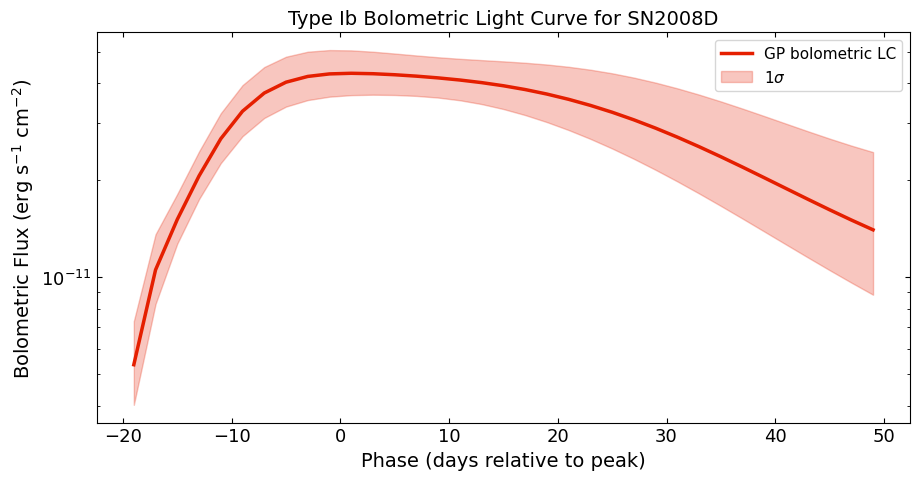

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(phases, F_bol, color=colors[0], lw=2.5,
        label='GP bolometric LC')
ax.fill_between(phases,
                F_low,
                F_up,
                alpha=0.25, color=colors[0], label=r'1$\sigma$')


ax.set_xlabel('Phase (days relative to peak)')
ax.set_ylabel(r"Bolometric Flux (erg s$^{-1}$ cm$^{-2}$)")
ax.set_title('Type Ib Bolometric Light Curve for SN2008D')
ax.legend(fontsize=11)
plt.tight_layout()

ax.set_yscale('log')
plt.show()

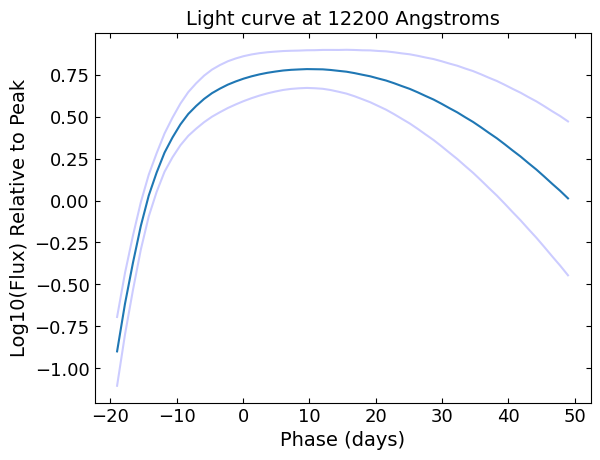

In [11]:
# An example predicted light curve
band = 'J'
phs, f, sigma = snmodel.predict_lightcurve(-19, 49, WLE[band])

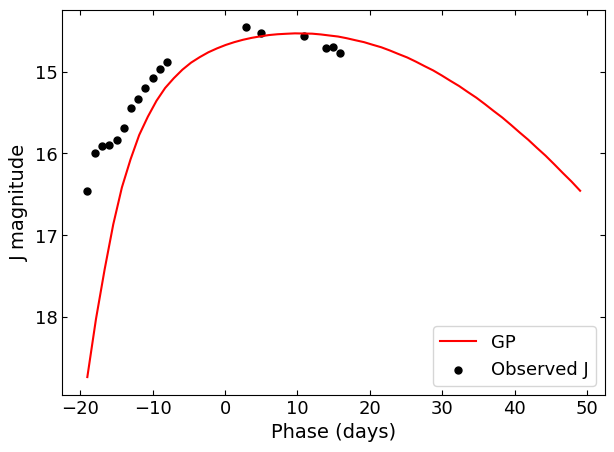

In [12]:
from caat.utils import convert_shifted_fluxes_to_shifted_mags

# Convert predicted shifted flux back to observed magnitude
mag_pred = (
    np.log10((10**(f + f_peak_ref_log)) / (SN08D.zps[band] * 1e-11))
    / -0.4
)

shifted_mags = convert_shifted_fluxes_to_shifted_mags(
    f,
    SN08D,
    SN08D.zps[band]
)

plt.figure(figsize=(7,5))

# GP prediction
plt.plot(phs, SN08D.info["peak_mag"]-shifted_mags, 'r-', label='GP')

# Original V-band data
vdata = SN08D.cube[SN08D.cube['ShiftedFilter']==band]
plt.scatter(vdata["Phase"], vdata["Mag"],
            color='k', s=25, label='Observed %s'%band)

plt.gca().invert_yaxis()
plt.xlabel("Phase (days)")
plt.ylabel("%s magnitude"%band)
plt.legend()

## Bolometric Luminosity for SN2008D

In [13]:
# from Modjaz et al. 2009: D = 31 ± 2 Mpc
d_L = 31 * u.Mpc.to(u.cm)
L_bol = 4 * np.pi * d_L**2 * F_bol
L_bol_up = 4 * np.pi * d_L**2 * F_up
L_bol_low = 4 * np.pi * d_L**2 * F_low


## Plotting Modjaz et al. 2009 bolometric lc for SN2008D

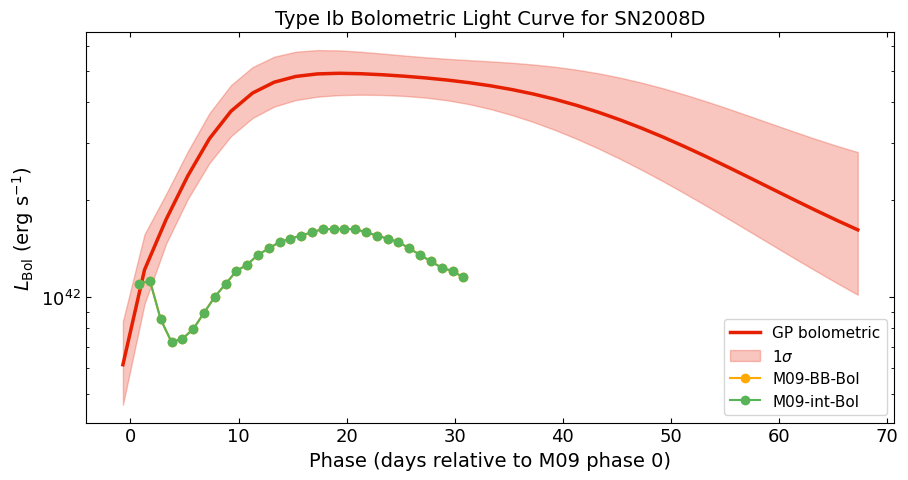

In [14]:
filename = "data/SN2008D_Modjaz09.txt"

phase_M09 = []
logL_M09_BB = []
logL_M09_int = []

with open(filename, "r") as f:
    for line in f:
        cols = line.strip().split("\t")

        # Skip lines that are not data
        if len(cols) < 4:
            continue

        try:
            t = float(cols[0])
            L = float(cols[3].split("^")[0])
            L2 = float(cols[4].split("^")[0])
            

            phase_M09.append(t)
            logL_M09_BB.append(L)
            logL_M09_int.append(L)

        except ValueError:
            continue
            
logL_M09_BB = np.asarray(logL_M09_BB)
logL_M09_int = np.asarray(logL_M09_int)
phase_M09 = np.asarray(phase_M09)


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(phases+18.3, L_bol, color=colors[0], lw=2.5,
        label='GP bolometric')

ax.fill_between(phases+18.3,
                L_bol_up,
                L_bol_low,
                alpha=0.25, color=colors[0], label=r'1$\sigma$')
ax.plot(phase_M09, 10**logL_M09_BB, "o-", color= colors[1], label='M09-BB-Bol')
ax.plot(phase_M09, 10**logL_M09_int, "o-", color = colors[2], label='M09-int-Bol')

ax.set_xlabel('Phase (days relative to M09 phase 0)')
ax.set_ylabel(r"$L_{\rm Bol}$ (erg s$^{-1}$)")
ax.set_title('Type Ib Bolometric Light Curve for SN2008D')
ax.legend(fontsize=11)
plt.tight_layout()
# ax.set_ylim(1e38, 1e43)
ax.set_yscale('log')
# ax.set_xlim(0.7
#             , 40)
# ax.set_xscale('log')
plt.show()